In [ ]:
#MUTIVARIATE ANALYSIS AND PREDICTION OF CH₄(METHANE) AND N₂O(NITROUS OXIDE) EMISSIONS ACROSS COUNTRIES

'''
How do per-capita CH₄ and N₂O emissions vary across countries and world regions, 
and how effectively can emission reduction status—defined as a binary indicator of 
whether a country has reduced emissions since 1990—be predicted using per-capita emissions and geographic classification?
'''

In [32]:
library(tidyverse)
library(skimr)
library(janitor)
library(ggplot2)

In [7]:
getwd()

[1] "C:/Users/admin/Data Visualization"

In [8]:
setwd("C:/Users/admin/Data Visualization")

In [35]:
#Data Acquisition
df <- read.csv("CH4_N2O_Emissions.csv", 
               stringsAsFactors = FALSE,
               na.strings = c("...", "", "NA")) %>%
  as_tibble()

In [36]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [37]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA


In [38]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [15]:
#Data Schema and variable definitions
dim(df)

[1] 204   9

In [16]:
names(df)

[1] "Country"                  "latest.year.available"   
[3] "CH4.emissions"            "CH4.emissions.per.capita"
[5] "X..change.since.1990"     "N2O.emissions"           
[7] "N2O.emissions.per.capita" "X..change.since.1990.1"  
[9] "X"

In [17]:
glimpse(df)

Rows: 204
Columns: 9
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <chr> "0.42", "0.68", "1.06", "1.11", "1.83", "2.29…
$ X..change.since.1990     <chr> "...", "...", "...", "...", "43.74", "10.50",…
$ N2O.emissions            <chr> "5.94", "0.29", "6.50", "13.87", "0.08", "67.…
$ N2O.emissions.per.capita <chr> "0.24", "0.09", "0.21", "0.77", "1.08", "1.82…
$ X..change.since.1990.1   <chr> "...", "...", "...", "...", "5197.47", "30.26…
$ X                        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [18]:
str(df)

tibble [204 × 9] (S3: tbl_df/tbl/data.frame)
 $ Country                 : chr [1:204] "Afghanistan" "Albania" "Algeria" "Angola" ...
 $ latest.year.available   : int [1:204] 2005 1994 2000 2005 2000 2000 2010 2012 2012 1994 ...
 $ CH4.emissions           : num [1:204] 10.16 2.14 32.92 19.93 0.14 ...
 $ CH4.emissions.per.capita: chr [1:204] "0.42" "0.68" "1.06" "1.11" ...
 $ X..change.since.1990    : chr [1:204] "..." "..." "..." "..." ...
 $ N2O.emissions           : chr [1:204] "5.94" "0.29" "6.50" "13.87" ...
 $ N2O.emissions.per.capita: chr [1:204] "0.24" "0.09" "0.21" "0.77" ...
 $ X..change.since.1990.1  : chr [1:204] "..." "..." "..." "..." ...
 $ X                       : logi [1:204] NA NA NA NA NA NA ...


In [29]:
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                       20                       20 
CH4.emissions.per.capita     X..change.since.1990            N2O.emissions 
                       0                        0                        0 
N2O.emissions.per.capita   X..change.since.1990.1                        X 
                       0                        0                      204

In [20]:
#Basic descriptive statistics
summary(df)

   Country          latest.year.available CH4.emissions    
 Length:204         Min.   :1990          Min.   :  0.000  
 Class :character   1st Qu.:2000          1st Qu.:  1.290  
 Mode  :character   Median :2000          Median :  5.075  
                    Mean   :2003          Mean   : 30.878  
                    3rd Qu.:2010          3rd Qu.: 20.430  
                    Max.   :2012          Max.   :932.860  
                    NA's   :20            NA's   :20       
 CH4.emissions.per.capita X..change.since.1990 N2O.emissions     
 Length:204               Length:204           Length:204        
 Class :character         Class :character     Class :character  
 Mode  :character         Mode  :character     Mode  :character  
                                                                 
                                                                 
                                                                 
                                                          

In [36]:
df_stats<- df%>%
summarize(
    Mean_df = mean(CH4.emissions, na.rm = TRUE),
    Variance_df = var(CH4.emissions, na.rm = TRUE),
    N_Observations = n()
  )
df_stats

Mean_df,Variance_df,N_Observations
<dbl>,<dbl>,<int>
30.87837,9454.304,204


In [38]:
regional_summary<-df%>%group_by(Country) %>%
  summarize(
    Avg_Emission = mean(CH4.emissions, na.rm = TRUE)
  ) %>%
  arrange(desc(Avg_Emission))

print(regional_summary)

# A tibble: 185 × 2
   Country                  Avg_Emission
   <chr>                           <dbl>
 1 China                           933. 
 2 United States of America        552. 
 3 Russian Federation              503. 
 4 India                           407. 
 5 Brazil                          316. 
 6 Indonesia                       236. 
 7 Mexico                          188. 
 8 Australia                       112. 
 9 Canada                           90.6
10 Uzbekistan                       89.4
# ℹ 175 more rows


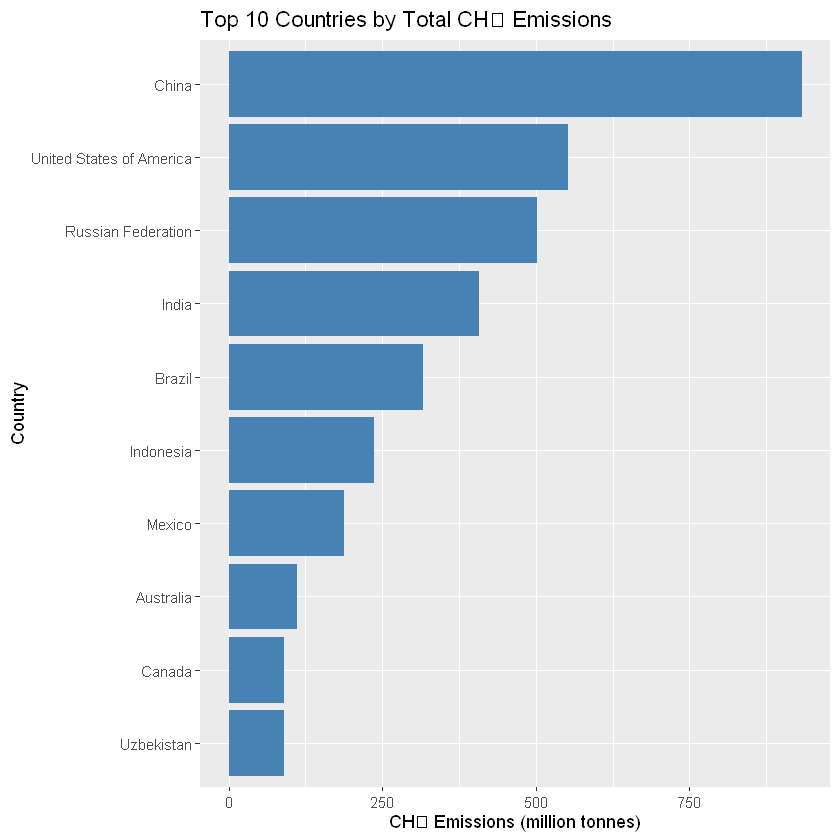

In [62]:
top_ch4 <- df %>% 
  arrange(desc(CH4.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, CH4.emissions), y = CH4.emissions)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total CH₄ Emissions",
       x = "Country", y = "CH₄ Emissions (million tonnes)")


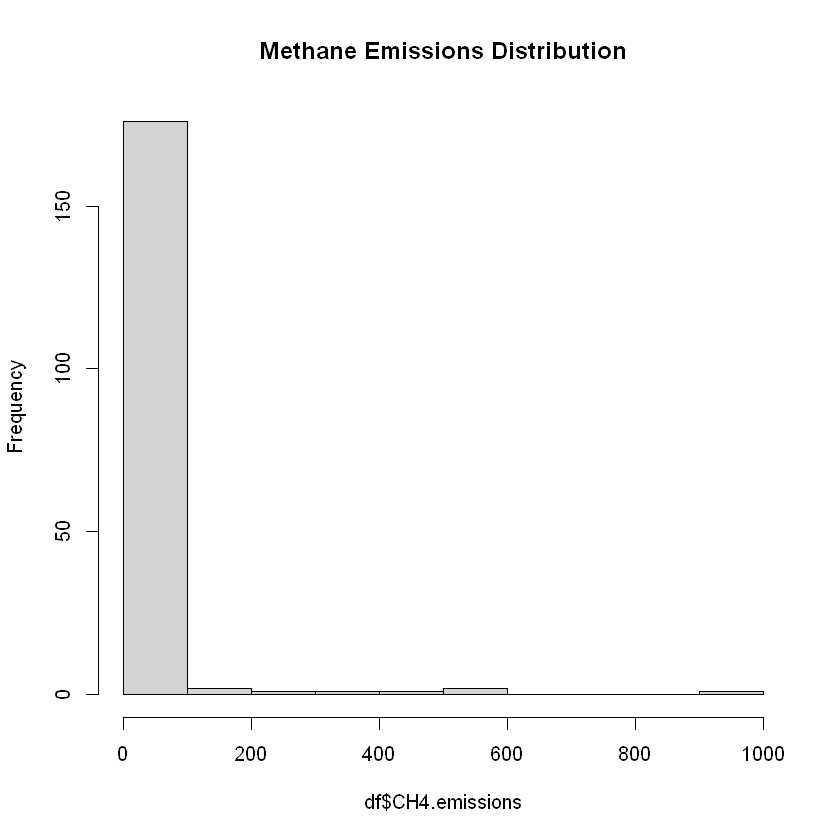

In [11]:
hist(df$CH4.emissions, main="Methane Emissions Distribution")

In [39]:
#Milestone 2
skim(df)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,logical.mean,logical.count,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,Country,20,0.9019608,4,52,0,184,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,character,N2O.emissions,21,0.8970588,1,6,0,154,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,character,N2O.emissions.per.capita,21,0.8970588,1,6,0,106,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,character,X..change.since.1990.1,118,0.4215686,1,7,0,82,0,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,logical,X,204,0.0000000,NA,NA,NA,NA,NA,NaN,:,NA,NA,NA,NA,NA,NA,NA,NA
6,numeric,latest.year.available,20,0.9019608,NA,NA,NA,NA,NA,NA,NA,2002.956522,6.64463,1990.00,2000.000,2000.000,2010.000,2012.00,▅▁▇▅▇
7,numeric,CH4.emissions,20,0.9019608,NA,NA,NA,NA,NA,NA,NA,30.878370,97.23325,0.00,1.290,5.075,20.430,932.86,▇▁▁▁▁
8,numeric,CH4.emissions.per.capita,21,0.8970588,NA,NA,NA,NA,NA,NA,NA,3.085574,22.89403,0.02,0.545,0.800,1.275,309.10,▇▁▁▁▁
9,numeric,X..change.since.1990,118,0.4215686,NA,NA,NA,NA,NA,NA,NA,-2.875465,39.88466,-59.24,-33.820,-7.035,13.105,122.72,▆▇▂▁▁


In [74]:
install.packages("GGally")

Installing package into 'C:/Users/admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'patchwork', 'ggstats'




package 'patchwork' successfully unpacked and MD5 sums checked
package 'ggstats' successfully unpacked and MD5 sums checked
package 'GGally' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\admin\AppData\Local\Temp\RtmpotAO4R\downloaded_packages


In [14]:
df <- na.omit(df)

In [16]:
df$latest.year.available <- as.integer(df$latest.year.available)

In [26]:
df$N2O.emissions <- as.double(df$N2O.emissions)

In [28]:
df$N2O.emissions.per.capita <- as.double(df$N2O.emissions.per.capita)

In [30]:
df$Total_Emissions <- df$CH4.emissions + df$N2O.emissions

In [21]:
df_grouped <- df %>%
  group_by(Country) %>%
  summarise(CH4_mean = mean(CH4.emissions), N2O_mean = mean(N2O.emissions))

In [29]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X,Year,Total_Emissions,CH4_growth
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<dbl>,<dbl>


In [24]:
df <- df %>%
  group_by(Country) %>%
  mutate(CH4_growth = (CH4.emissions - lag(CH4.emissions)) / lag(CH4.emissions))